In [1]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import sinter
import matplotlib.pyplot as plt
import os

from qecdec.experiments import RotatedSurfaceCode_Memory
from qecdec.decoders import DMemBPDecoder
from qecdec.sinter_utils import QecdecSinterDecoder

In [2]:
d = 5
rounds = 5
p = 0.01
norm_list = np.arange(0, 1.0001, 0.05).tolist()
max_iter = 50

expmt = RotatedSurfaceCode_Memory(
    d=d,
    rounds=rounds,
    basis="Z",
    data_qubit_error_rate=p,
    meas_error_rate=p,
)

seeds = [0, 1, 2, 3]
gamma_list: list[np.ndarray] = []
for seed in seeds:
    rng = np.random.default_rng(seed)
    gamma_list.append(rng.uniform(-0.1, 0.8, expmt.num_error_mechanisms))


In [3]:
def generate_sinter_tasks_and_custom_decoders():
    tasks: list[sinter.Task] = []
    custom_decoders: dict[str, sinter.Decoder] = {}
    for seed, gamma in zip(seeds, gamma_list):
        for norm in norm_list:
            # Setup a sinter.Task with BP decoder.
            dmembp = DMemBPDecoder(
                expmt.chkmat,
                expmt.prior,
                gamma=gamma,
                max_iter=max_iter,
                norm=norm,
            )
            custom_decoder_id = f"custom_decoder_{len(custom_decoders)}"
            custom_decoders[custom_decoder_id] = QecdecSinterDecoder(
                dmembp, expmt.obsmat
            )
            tasks.append(
                sinter.Task(
                    circuit=expmt.circuit,
                    detector_error_model=expmt.dem,
                    decoder=custom_decoder_id,
                    json_metadata={"gamma_seed": seed, "norm": norm},
                )
            )
    return tasks, custom_decoders


tasks, custom_decoders = generate_sinter_tasks_and_custom_decoders()


In [4]:
sinter_stats = sinter.collect(
    num_workers=os.cpu_count() - 1,
    max_shots=10_000_000,
    max_errors=100,
    tasks=tasks,
    custom_decoders=custom_decoders,
    print_progress=False,
)

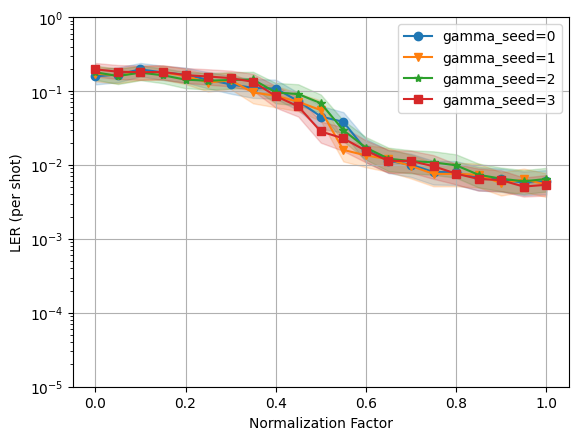

In [5]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=sinter_stats,
    group_func=lambda stat: f"gamma_seed={stat.json_metadata['gamma_seed']}",
    x_func=lambda stat: stat.json_metadata["norm"],
)
ax.semilogy()
ax.set_ylim(1e-5, 1)
ax.grid()
ax.set_ylabel("LER (per shot)")
ax.set_xlabel("Normalization Factor")
ax.legend()